In [1]:
from typing import TypedDict,Annotated
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import START,END,StateGraph
from langchain_core.messages import HumanMessage,BaseMessage
from langgraph.checkpoint.memory import MemorySaver

In [2]:
load_dotenv()

True

In [3]:
llm = ChatGoogleGenerativeAI(
    model="gemini-3.5-flash-lite"
)

In [4]:
from langgraph.graph.message import add_messages

class ChatState(TypedDict):
    messages:Annotated[list[BaseMessage],add_messages]

In [5]:
def chat_node(state:ChatState):
    messages=state['messages']
    response=llm.invoke(messages)
    return {'messages':[response]}


In [6]:
checkpoint = MemorySaver()

graph=StateGraph(ChatState)

# add node

graph.add_node("chat_node",chat_node)

# add edges
graph.add_edge(START,'chat_node')
graph.add_edge("chat_node",END)

chatbot=graph.compile(checkpointer=checkpoint)


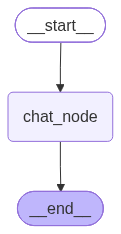

In [7]:
chatbot

In [8]:
thread_id='2'
initial_state = {
    'messages': [HumanMessage(content='What is  OOPs?')]
}
config={"configurable":{"thread_id":thread_id}}
response = chatbot.invoke(initial_state,config=config)

Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


In [9]:
response

{'messages': [HumanMessage(content='What is  OOPs?', additional_kwargs={}, response_metadata={}, id='db7fa863-37ed-4dcb-bf77-91d11b6e9a5e'),
  AIMessage(content=[{'type': 'text', 'text': '**OOPs** stands for **Object-Oriented Programming System**. \n\nIt is a programming paradigm (a style or way of thinking about and structuring code) that uses **objects** and **classes** to design applications and computer programs. \n\nInstead of writing code as a simple list of instructions (which is called Procedural Programming, like in C), OOPs models real-world entities, making code more modular, reusable, and easier to maintain.\n\n---\n\n### The 4 Core Pillars of OOPs\n\nObject-Oriented Programming is built on four main concepts (often remembered by the acronym **P**ie**IE**):\n\n#### 1. Encapsulation\n* **What it is:** Wrapping data (variables) and methods (functions) together into a single unit (called a **Class**). It also involves hiding the internal state of an object from the outside wor

In [10]:
response['messages'][-1].content

[{'type': 'text',
  'text': '**OOPs** stands for **Object-Oriented Programming System**. \n\nIt is a programming paradigm (a style or way of thinking about and structuring code) that uses **objects** and **classes** to design applications and computer programs. \n\nInstead of writing code as a simple list of instructions (which is called Procedural Programming, like in C), OOPs models real-world entities, making code more modular, reusable, and easier to maintain.\n\n---\n\n### The 4 Core Pillars of OOPs\n\nObject-Oriented Programming is built on four main concepts (often remembered by the acronym **P**ie**IE**):\n\n#### 1. Encapsulation\n* **What it is:** Wrapping data (variables) and methods (functions) together into a single unit (called a **Class**). It also involves hiding the internal state of an object from the outside world (using **private** or **protected** access modifiers).\n* **Real-world example:** A capsule of medicine. It contains various chemicals inside, but you just 

In [11]:
chatbot.get_state(config=config)

StateSnapshot(values={'messages': [HumanMessage(content='What is  OOPs?', additional_kwargs={}, response_metadata={}, id='db7fa863-37ed-4dcb-bf77-91d11b6e9a5e'), AIMessage(content=[{'type': 'text', 'text': '**OOPs** stands for **Object-Oriented Programming System**. \n\nIt is a programming paradigm (a style or way of thinking about and structuring code) that uses **objects** and **classes** to design applications and computer programs. \n\nInstead of writing code as a simple list of instructions (which is called Procedural Programming, like in C), OOPs models real-world entities, making code more modular, reusable, and easier to maintain.\n\n---\n\n### The 4 Core Pillars of OOPs\n\nObject-Oriented Programming is built on four main concepts (often remembered by the acronym **P**ie**IE**):\n\n#### 1. Encapsulation\n* **What it is:** Wrapping data (variables) and methods (functions) together into a single unit (called a **Class**). It also involves hiding the internal state of an object f

In [12]:
thread_id='1'
while True:
    user_message = input('Type here: ')

    print('User:', user_message)

    if user_message.strip().lower() in ['exit', 'quit', 'bye']:
        break

    config={'configurable':{"thread_id":thread_id}}
    response = chatbot.invoke({'messages': [HumanMessage(content=user_message)]},config=config)
    print('AI:', response['messages'][-1].content)

User: what is opps
AI: [{'type': 'text', 'text': 'Depending on the context, **"opps"** (or **"op"**) has a few different meanings:\n\n### 1. Slang / Hip-Hop Culture (Most Common Today)\nIn modern slang, "opps" is short for **"opposition"** or **"enemies."** \n* **Meaning:** It refers to rivals, gang members from a hostile neighborhood, or people you are in conflict with.\n* **Example:** *"He has to watch his back because he\'s hanging around the opps\' territory."*\n* **Origin:** It originated in Chicago hip-hop culture and spread globally through rap music and social media.\n\n### 2. Gaming (Short for "Opponents")\nIn video games, "opps" is often used as shorthand for opponents or enemies.\n* **Example:** *"Let\'s flank the opps from behind."*\n\n### 3. Typo for "Oops"\nSometimes, people accidentally type an extra "p" when trying to say "oops" (the exclamation used when you make a mistake).\n* **Example:** *"Opps, I dropped my coffee!"*\n\n***\n\n*If you saw "opps" used in a specific 